firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (5,) is empty. This is likely an error. Did you choose the right label?


(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

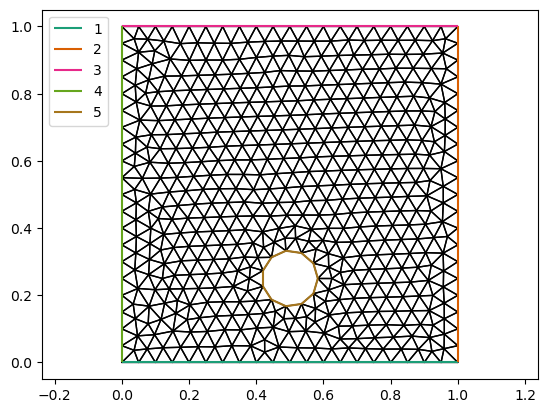

In [203]:
from firedrake import *
import numpy as np
import matplotlib.pyplot as plt

# geometry: unit square with a circular hole
mesh = Mesh('mesh/square_minus_circle.msh')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')
ax.axis('equal')

In [204]:
# Function spaces
V = VectorFunctionSpace(mesh, "P", 2)   # velocity
Q = FunctionSpace(mesh, "P", 1)         # pressure
W = MixedFunctionSpace([V, Q])
Z = FunctionSpace(mesh, "P", 1)         # temperature

# Data
nu = Constant(1e-2)
k = Constant(1.e-2)
beta = Constant(1.e-4)
g = Constant((0,-9.8))
T_ref = Constant(0)
f = Constant((0.,0.))
t0 = 0
tf = 100
dt = 1

# Boundary conditions

# Γ1: constant temperature rough bottom wall
# No-slip for the velocity: u = 0
bc_U_bottom = DirichletBC(V, Constant((0., 0.)), 1)
# Bottom temperature: T = 0
bc_T_bottom = DirichletBC(Z, Constant(0.), 1)

# Γ2, Γ3, Γ4: rough walls
# No-slip for the velocity: u = 0
bc_U_walls = DirichletBC(V, Constant((0., 0.)), [2,3,4])
# Homogeneous Neumann for the temperature
# /

# Γ5: cylinder
# No-slip for the velocity: u = 0
bc_U_cylinder = DirichletBC(V, Constant((0., 0.)), 5)
# Dirichlet for the temperature
bc_T_cylinder = DirichletBC(Z, Constant(30.), 5)

bcsU = [bc_U_bottom, bc_U_walls, bc_U_cylinder]
bcsT = [bc_T_bottom, bc_T_cylinder]


In [205]:
# Forms for incremental Chorin-Temam scheme

# Step 1
# u, v          : trial and test function for the predictor problem
# u_old, p_old  : solution from previous time step
# T_old, T_ref  : temperature from previous time step and reference temperature
def predictor_forms(u, v, nu, dt, u_old, p_old, T_old, T_ref):
    a = (1/dt)*inner(u, v)*dx + inner(dot(grad(u), u_old), v)*dx + Constant(nu)*inner(grad(u), grad(v))*dx
    L = (1/dt)*inner(u_old, v)*dx - inner(grad(p_old), v)*dx - Constant(beta)*(T_old - T_ref)*inner(g, v)*dx
    return a, L

# Step 2
# dp, q         : trial and test function for the (incremental) pressure problem
# u_tilde       : solution of predictor problem
def pressure_forms(dp, q, dt, u_tilde):
    a = inner(grad(dp), grad(q))*dx
    L = -(1/dt)*div(u_tilde)*q*dx
    return a, L

# Step 3
# ATTENTION: uh and grad(ph) belong to different FE spaces
# u, v          : trial and test function for the predictor problem
# u_tilde       : solution of predictor problem
# dp            : solution of (incremental) pressure problem
def projection_forms(u, v, u_tilde, dp, dt):
    # u = u_tilde - dt*grad(dp)
    a = inner(u, v)*dx
    L = inner(u_tilde, v)*dx - dt*inner(grad(dp), v)*dx
    return a, L

# Step 4
# T         :   TrialFunction
# eta       :   TestFunction
# uh        :   advecting velocity Function
# T_old     :   old temperature Function
def time_step_temperature(T, eta, uh, dt, T_old):
    a = Constant(1/dt) * inner(T, eta) * dx + Constant(k) * inner(grad(T), grad(eta)) * dx + inner(dot(grad(T), uh), eta) * dx
    L = Constant(1/dt) * inner(T_old, eta) * dx
    return a, L

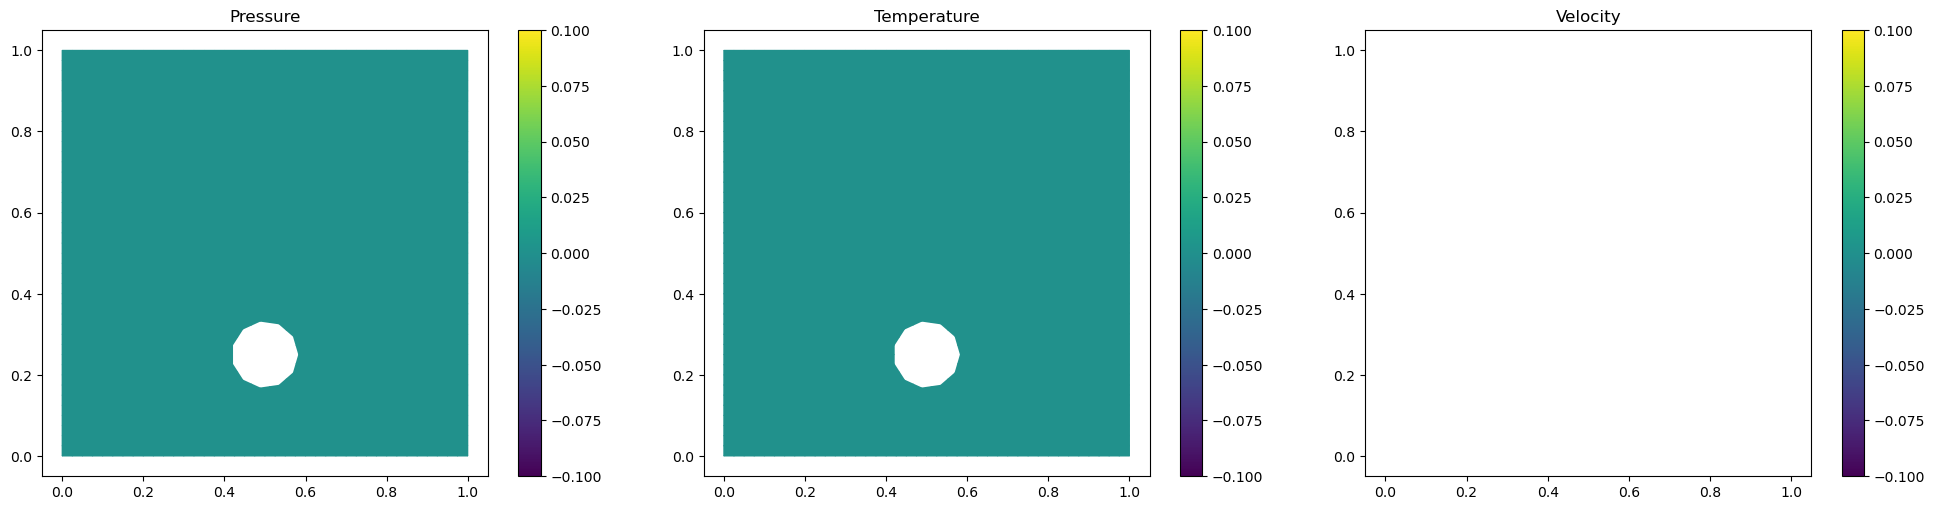

In [206]:
# Functions for the variational problems
u = TrialFunction(V)    # u_tilde
v = TestFunction(V)     # test function for the predictor problem
dp = TrialFunction(Q)   # increment of pressure
q = TestFunction(Q)     # test function for the pressure problem
T = TrialFunction(Z)    # temperature
eta = TestFunction(Z)   # test function for the temperature problem

# Initial conditions
uh = Function(V)        # solution of predictor problem and velocity at the new time step
dph = Function(Q)       # increment of pressure
Th = Function(Z)        # temperature at the new time step
u_old = Function(V)     # velocity at the previous time step
T_old = Function(Z)     # temperature at the previous time step
p_old = Function(Q)     # pressure at the previous time step

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

col0 = tripcolor(p_old, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('Pressure')
ax[0].set_aspect('equal')

col1 = tripcolor(T_old, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('Temperature')
ax[1].set_aspect('equal')

col2 = quiver(u_old, axes=ax[2])
fig.colorbar(col2, ax=ax[2])
ax[2].set_title('Velocity')
ax[2].set_aspect('equal')

plt.tight_layout()

# vtk output for Paraview
outfile = VTKFile("output/090124/solution.pvd")
u_old.rename("Velocity")   # this names will be used in Paraview
p_old.rename("Pressure")
T_old.rename("Temperature")
outfile.write(u_old, p_old, T_old, time=t0)

In [207]:
# Time loop

# Step 1
predictor_a, predictor_L = predictor_forms(u, v, nu, dt, u_old, p_old, T_old, T_ref)
predictor_problem = LinearVariationalProblem(predictor_a, predictor_L, uh, bcs=bcsU)
solver_predictor = LinearVariationalSolver(predictor_problem)
# Step 2
nullspace = VectorSpaceBasis(constant=True, comm=COMM_WORLD)
pressure_a, pressure_L = pressure_forms(dp, q, dt, uh)
pressure_problem = LinearVariationalProblem(pressure_a, pressure_L, dph)
parameters = {'ksp_type': 'gmres', 'pc_type': 'ilu', 'ksp_rtol': 1.e-8, 'ksp_max_it': 1000}
solver_pressure = LinearVariationalSolver(pressure_problem, solver_parameters=parameters, nullspace=nullspace)
# Step 3
projection_a, projection_L = projection_forms(u, v, uh, dph, dt)
projection_problem = LinearVariationalProblem(projection_a, projection_L, uh, bcs=bcsU)
solver_projection = LinearVariationalSolver(projection_problem)
# Step 4
a_T, L_T = time_step_temperature(T, eta, uh, dt, T_old)
problem_T = LinearVariationalProblem(a_T, L_T, Th, bcs=bcsT)
solver_T = LinearVariationalSolver(problem_T)

nsteps = int(tf/dt) + 1
step = 0
for t in np.linspace(dt, tf, int(tf/dt)):   
    step += 1
    
    solver_predictor.solve()
    solver_pressure.solve()
    solver_projection.solve()
    solver_T.solve()

    # Update solutions and parameters for next time step
    u_old.assign(uh)
    T_old.assign(Th)
    p_old.dat += dph.dat
    
    uh.rename("Velocity")
    ph.rename("Pressure")
    Th.rename("Temperature")
    outfile.write(u_old, p_old, T_old, time=t)

    print(f"Time = {t:.2f}")


Time = 1.00
Time = 2.00
Time = 3.00
Time = 4.00
Time = 5.00
Time = 6.00
Time = 7.00
Time = 8.00
Time = 9.00
Time = 10.00
Time = 11.00
Time = 12.00
Time = 13.00
Time = 14.00
Time = 15.00
Time = 16.00
Time = 17.00
Time = 18.00
Time = 19.00
Time = 20.00
Time = 21.00
Time = 22.00
Time = 23.00
Time = 24.00
Time = 25.00
Time = 26.00
Time = 27.00
Time = 28.00
Time = 29.00
Time = 30.00
Time = 31.00
Time = 32.00
Time = 33.00
Time = 34.00
Time = 35.00
Time = 36.00
Time = 37.00
Time = 38.00
Time = 39.00
Time = 40.00
Time = 41.00
Time = 42.00
Time = 43.00
Time = 44.00
Time = 45.00
Time = 46.00
Time = 47.00
Time = 48.00
Time = 49.00
Time = 50.00
Time = 51.00
Time = 52.00
Time = 53.00
Time = 54.00
Time = 55.00
Time = 56.00
Time = 57.00
Time = 58.00
Time = 59.00
Time = 60.00
Time = 61.00
Time = 62.00
Time = 63.00
Time = 64.00
Time = 65.00
Time = 66.00
Time = 67.00
Time = 68.00
Time = 69.00
Time = 70.00
Time = 71.00
Time = 72.00
Time = 73.00
Time = 74.00
Time = 75.00
Time = 76.00
Time = 77.00
Time = 7

Mean temperature in the domain: 17.42


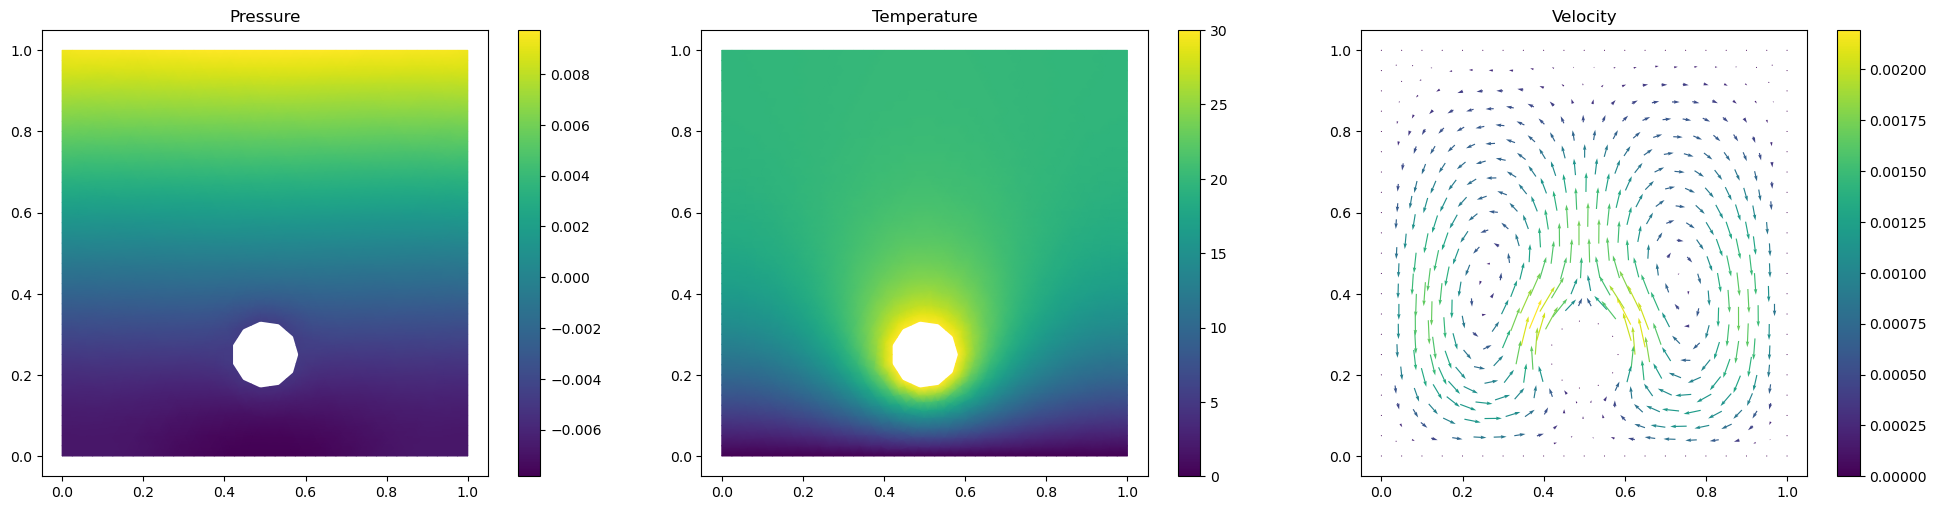

In [208]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

col0 = tripcolor(p_old, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('Pressure')
ax[0].set_aspect('equal')

col1 = tripcolor(T_old, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('Temperature')
ax[1].set_aspect('equal')


col2 = quiver(u_old, axes=ax[2])
fig.colorbar(col2, ax=ax[2])
ax[2].set_title('Velocity')
ax[2].set_aspect('equal')

plt.tight_layout()

# Compute the mean temperature in the domain
mean_temperature = assemble(T_old * dx) / assemble(1.0 * dx(mesh))
print(f"Mean temperature in the domain: {mean_temperature:.2f}")